In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', context='notebook')

In [2]:
df = pd.read_csv('ushape.csv')
display(df.head(10))
print(f'Shape: {df.shape}')
print(f'Features: {df.columns[:2].tolist()}')
print(f'Target: {df.columns[-1]}')
print(df['class'].value_counts().sort_index())

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0
5,2.1100,0.6620,1.0
6,0.5700,0.3370,0.0
7,0.9520,-0.7530,1.0
8,-0.0292,0.3930,1.0
9,1.7200,0.3610,1.0


Shape: (100, 3)
Features: ['X', 'Y']
Target: class
class
0.0    50
1.0    50
Name: count, dtype: int64


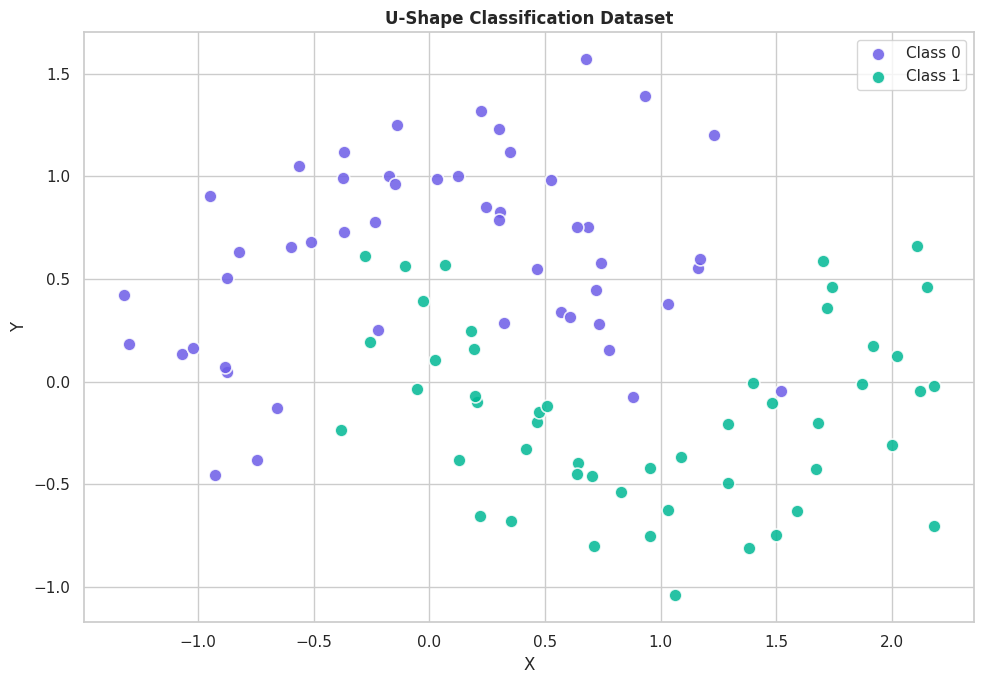

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
palette = ['#6C5CE7', '#00B894']

for label, color in zip(sorted(df['class'].unique()), palette):
    part = df[df['class'] == label]
    ax.scatter(part['X'], part['Y'], s=85, c=color, alpha=0.85, edgecolor='white', linewidth=1.2, label=f'Class {int(label)}')

ax.set_title('U-Shape Classification Dataset', fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

In [4]:
X = df[['X', 'Y']].to_numpy(dtype=np.float32)
y = df['class'].to_numpy(dtype=np.float32)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('X mean:', X.mean(axis=0))
print('X std :', X.std(axis=0))

X shape: (100, 2)
y shape: (100,)
X mean: [0.500579   0.22868839]
X std : [0.8867958  0.59005076]


In [5]:
fan_in = X.shape[1]
fan_out = 10

he_std = np.sqrt(2 / fan_in)
xavier_std = np.sqrt(1 / fan_in)
he_limit = np.sqrt(6 / fan_in)
xavier_limit = np.sqrt(6 / (fan_in + fan_out))

scale_table = pd.DataFrame({
    'Initializer': ['He Normal', 'Xavier Normal', 'He Uniform', 'Xavier Uniform'],
    'Std / Limit': [he_std, xavier_std, he_limit, xavier_limit]
})
display(scale_table)

,Initializer,Std / Limit
0,He Normal,1.000000
1,Xavier Normal,0.707107
2,He Uniform,1.732051
3,Xavier Uniform,0.707107


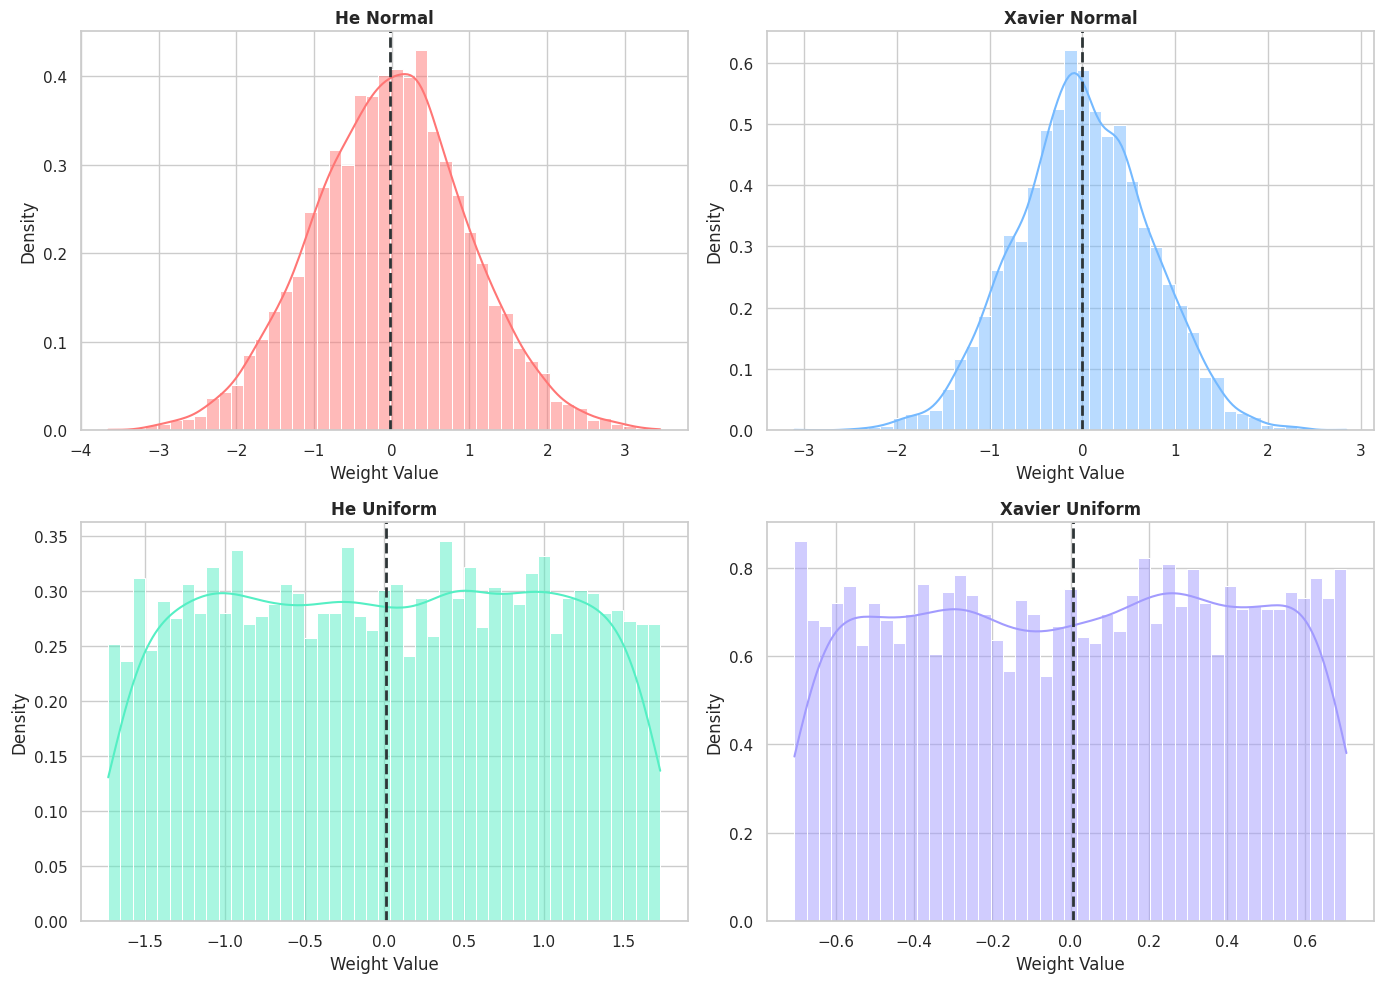

In [6]:
rng = np.random.default_rng(SEED)
n = 5000

he_normal_samples = rng.normal(0, he_std, n)
xavier_normal_samples = rng.normal(0, xavier_std, n)
he_uniform_samples = rng.uniform(-he_limit, he_limit, n)
xavier_uniform_samples = rng.uniform(-xavier_limit, xavier_limit, n)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plots = [
    (he_normal_samples, '#FF7675', 'He Normal'),
    (xavier_normal_samples, '#74B9FF', 'Xavier Normal'),
    (he_uniform_samples, '#55EFC4', 'He Uniform'),
    (xavier_uniform_samples, '#A29BFE', 'Xavier Uniform')
]

for ax, (values, color, title) in zip(axes.ravel(), plots):
    sns.histplot(values, bins=45, kde=True, color=color, ax=ax, stat='density')
    ax.axvline(values.mean(), color='#2D3436', linestyle='--', linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [7]:
def build_model(initializer):
    model = Sequential([
        Dense(10, activation='relu', input_shape=(2,), kernel_initializer=initializer),
        Dense(10, activation='relu', kernel_initializer=initializer),
        Dense(10, activation='relu', kernel_initializer=initializer),
        Dense(10, activation='relu', kernel_initializer=initializer),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

he_normal_init = keras.initializers.HeNormal(seed=SEED)
he_uniform_init = keras.initializers.HeUniform(seed=SEED)
xavier_normal_init = keras.initializers.GlorotNormal(seed=SEED)
xavier_uniform_init = keras.initializers.GlorotUniform(seed=SEED)

model = build_model(he_normal_init)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
initial_weights = model.get_weights()

weight_rows = []
for i, weight in enumerate(initial_weights):
    if weight.ndim == 2:
        weight_rows.append({
            'Tensor': f'W{i//2 + 1}',
            'Shape': weight.shape,
            'Mean': weight.mean(),
            'Std': weight.std(),
            'Min': weight.min(),
            'Max': weight.max()
        })

weights_df = pd.DataFrame(weight_rows)
display(weights_df.style.format({'Mean':'{:.5f}','Std':'{:.5f}','Min':'{:.5f}','Max':'{:.5f}'}))

,Tensor,Shape,Mean,Std,Min,Max
0,W1,"(2, 10)",0.09280,0.80839,-1.80769,1.57436
1,W2,"(10, 10)",0.01603,0.42845,-0.97210,0.93513
2,W3,"(10, 10)",0.01603,0.42845,-0.97210,0.93513
3,W4,"(10, 10)",0.01603,0.42845,-0.97210,0.93513
4,W5,"(10, 1)",0.12598,0.43191,-0.62325,0.69497


In [9]:
initializers = {
    'He Normal': he_normal_init,
    'He Uniform': he_uniform_init,
    'Xavier Normal': xavier_normal_init,
    'Xavier Uniform': xavier_uniform_init
}

stats = []
for name, initializer in initializers.items():
    temp = build_model(initializer)
    for layer_no, layer in enumerate(temp.layers[:-1], start=1):
        w = layer.get_weights()[0]
        stats.append({
            'Initializer': name,
            'Layer': f'Layer {layer_no}',
            'Mean': w.mean(),
            'Std': w.std(),
            'Abs Mean': np.abs(w).mean(),
            'L2 Norm': np.linalg.norm(w)
        })

stats_df = pd.DataFrame(stats)
display(stats_df.style.format({'Mean':'{:.5f}','Std':'{:.5f}','Abs Mean':'{:.5f}','L2 Norm':'{:.5f}'}))

,Initializer,Layer,Mean,Std,Abs Mean,L2 Norm
0,He Normal,Layer 1,0.09280,0.80839,0.57610,3.63899
1,He Normal,Layer 2,0.01603,0.42845,0.35733,4.28748
2,He Normal,Layer 3,0.01603,0.42845,0.35733,4.28748
3,He Normal,Layer 4,0.01603,0.42845,0.35733,4.28748
4,He Uniform,Layer 1,-0.32383,0.95177,0.86870,4.49608
5,He Uniform,Layer 2,-0.03038,0.43807,0.37976,4.39123
6,He Uniform,Layer 3,-0.03038,0.43807,0.37976,4.39123
7,He Uniform,Layer 4,-0.03038,0.43807,0.37976,4.39123
8,Xavier Normal,Layer 1,0.03788,0.33003,0.23519,1.48561
9,Xavier Normal,Layer 2,0.01134,0.30296,0.25267,3.03171


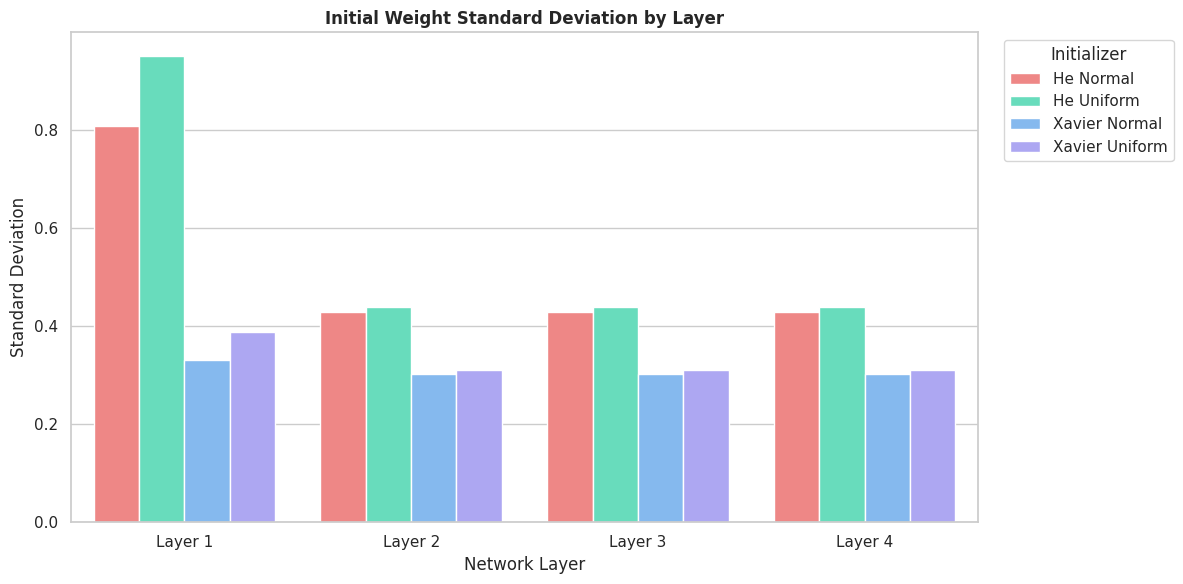

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=stats_df, x='Layer', y='Std', hue='Initializer', palette=['#FF7675','#55EFC4','#74B9FF','#A29BFE'], ax=ax)
ax.set_title('Initial Weight Standard Deviation by Layer', fontweight='bold')
ax.set_ylabel('Standard Deviation')
ax.set_xlabel('Network Layer')
plt.legend(title='Initializer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [11]:
results = {}
trained_models = {}

initializer_map = {
    'He Normal': keras.initializers.HeNormal(seed=SEED),
    'He Uniform': keras.initializers.HeUniform(seed=SEED),
    'Xavier Normal': keras.initializers.GlorotNormal(seed=SEED),
    'Xavier Uniform': keras.initializers.GlorotUniform(seed=SEED)
}

for name, initializer in initializer_map.items():
    tf.keras.backend.clear_session()
    current_model = build_model(initializer)
    current_history = current_model.fit(
        X, y,
        epochs=200,
        validation_split=0.2,
        batch_size=16,
        verbose=0
    )
    trained_models[name] = current_model
    results[name] = current_history.history
    print(f'{name}: final accuracy = {current_history.history["accuracy"][-1]:.4f}, final val_accuracy = {current_history.history["val_accuracy"][-1]:.4f}')

He Normal: final accuracy = 0.9875, final val_accuracy = 0.9500
He Uniform: final accuracy = 0.9875, final val_accuracy = 0.9500
Xavier Normal: final accuracy = 0.9875, final val_accuracy = 0.9000
Xavier Uniform: final accuracy = 0.9875, final val_accuracy = 0.9500


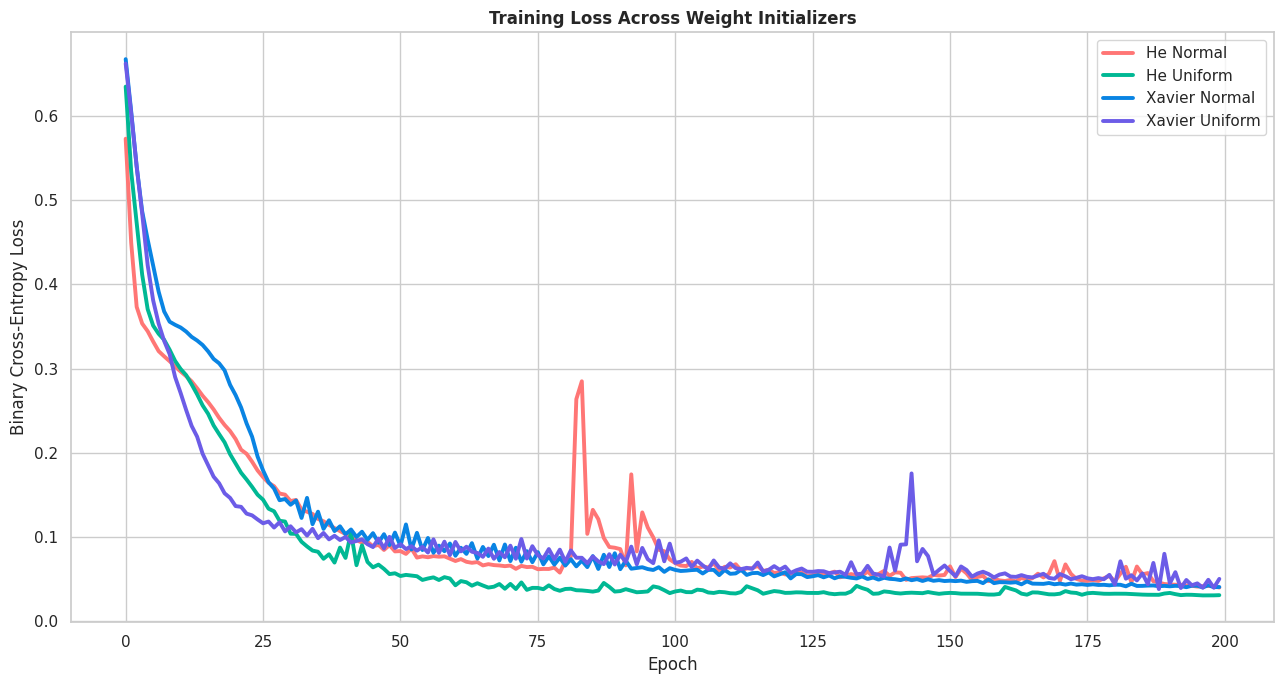

In [12]:
palette_map = {
    'He Normal': '#FF7675',
    'He Uniform': '#00B894',
    'Xavier Normal': '#0984E3',
    'Xavier Uniform': '#6C5CE7'
}

fig, ax = plt.subplots(figsize=(13, 7))
for name, history in results.items():
    ax.plot(history['loss'], linewidth=2.8, color=palette_map[name], label=name)
ax.set_title('Training Loss Across Weight Initializers', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary Cross-Entropy Loss')
ax.legend()
plt.tight_layout()
plt.show()

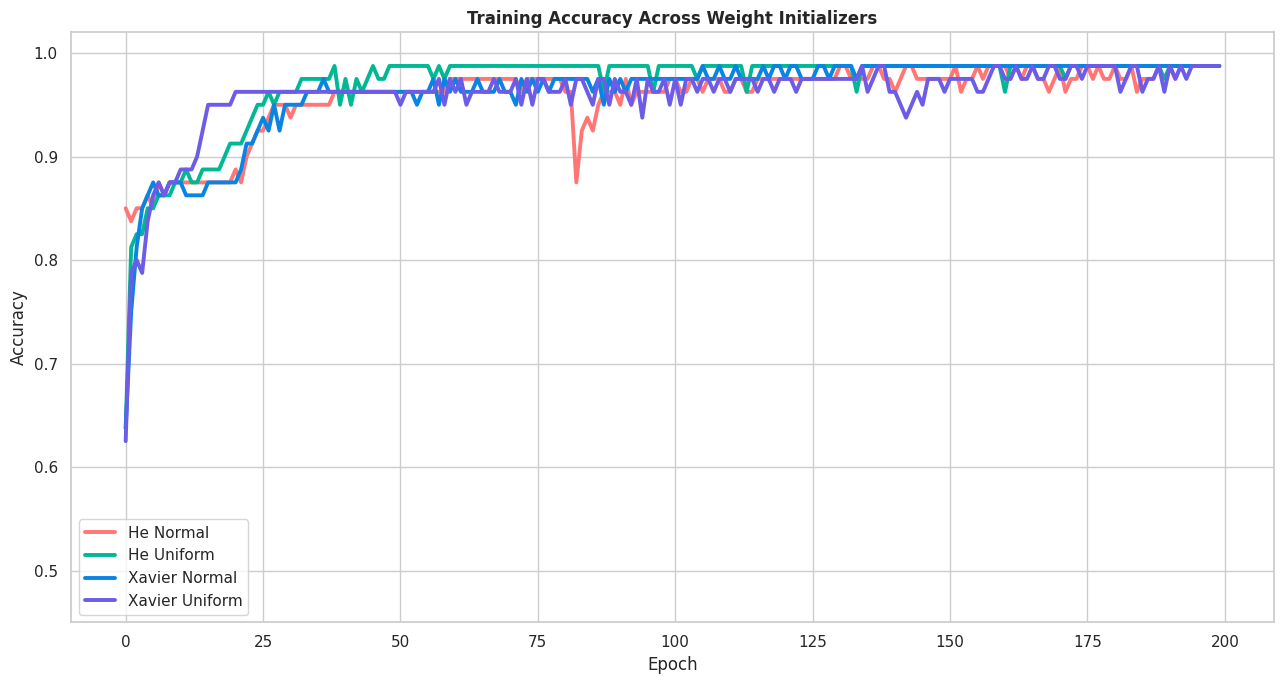

In [13]:
fig, ax = plt.subplots(figsize=(13, 7))
for name, history in results.items():
    ax.plot(history['accuracy'], linewidth=2.8, color=palette_map[name], label=name)
ax.set_title('Training Accuracy Across Weight Initializers', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.45, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

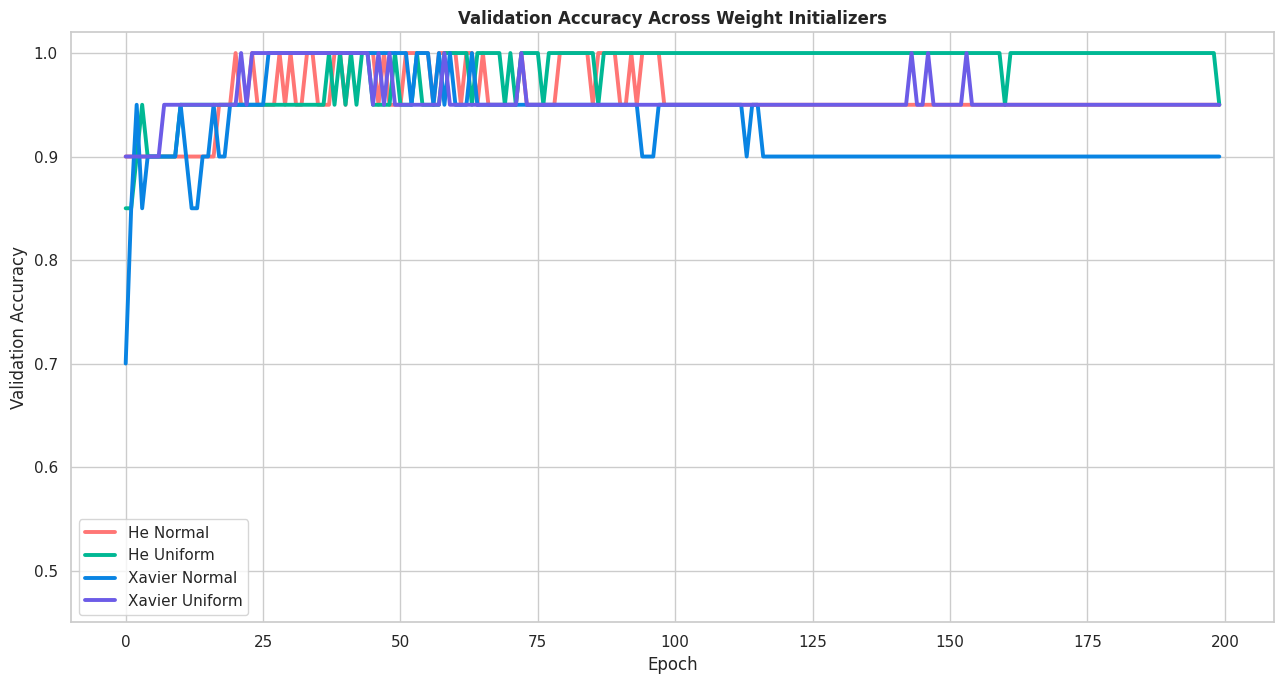

In [14]:
fig, ax = plt.subplots(figsize=(13, 7))
for name, history in results.items():
    ax.plot(history['val_accuracy'], linewidth=2.8, color=palette_map[name], label=name)
ax.set_title('Validation Accuracy Across Weight Initializers', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0.45, 1.02)
ax.legend()
plt.tight_layout()
plt.show()


In [15]:
comparison = pd.DataFrame([
    {
        'Initializer': name,
        'Final Train Loss': results[name]['loss'][-1],
        'Final Train Accuracy': results[name]['accuracy'][-1],
        'Final Validation Loss': results[name]['val_loss'][-1],
        'Final Validation Accuracy': results[name]['val_accuracy'][-1],
        'Best Validation Accuracy': max(results[name]['val_accuracy'])
    }
    for name in results
])

display(comparison.sort_values('Best Validation Accuracy', ascending=False).style.format({
    'Final Train Loss':'{:.4f}',
    'Final Train Accuracy':'{:.4f}',
    'Final Validation Loss':'{:.4f}',
    'Final Validation Accuracy':'{:.4f}',
    'Best Validation Accuracy':'{:.4f}'
}))

,Initializer,Final Train Loss,Final Train Accuracy,Final Validation Loss,Final Validation Accuracy,Best Validation Accuracy
0,He Normal,0.0395,0.9875,0.3200,0.9500,1.0000
1,He Uniform,0.0305,0.9875,0.0680,0.9500,1.0000
2,Xavier Normal,0.0402,0.9875,0.1547,0.9000,1.0000
3,Xavier Uniform,0.0498,0.9875,0.0931,0.9500,1.0000


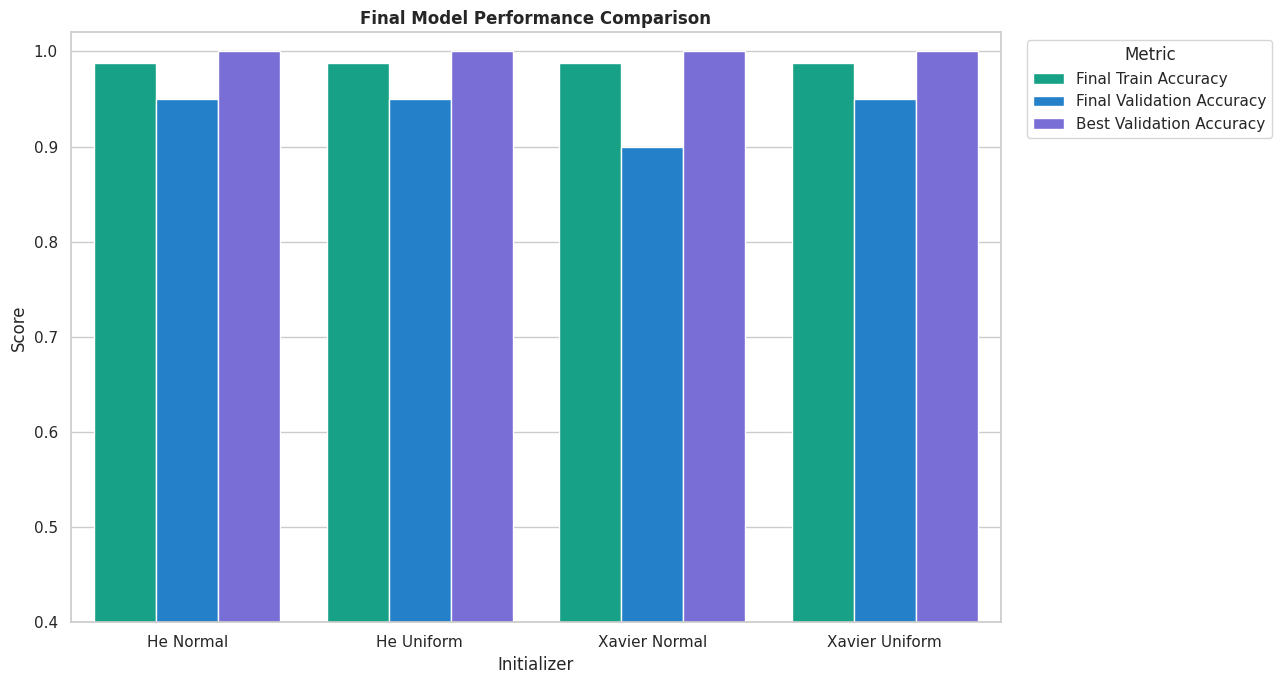

In [16]:
melted = comparison.melt(
    id_vars='Initializer',
    value_vars=['Final Train Accuracy', 'Final Validation Accuracy', 'Best Validation Accuracy'],
    var_name='Metric',
    value_name='Score'
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=melted, x='Initializer', y='Score', hue='Metric', palette=['#00B894','#0984E3','#6C5CE7'], ax=ax)
ax.set_title('Final Model Performance Comparison', fontweight='bold')
ax.set_ylabel('Score')
ax.set_xlabel('Initializer')
ax.set_ylim(0.4, 1.02)
plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

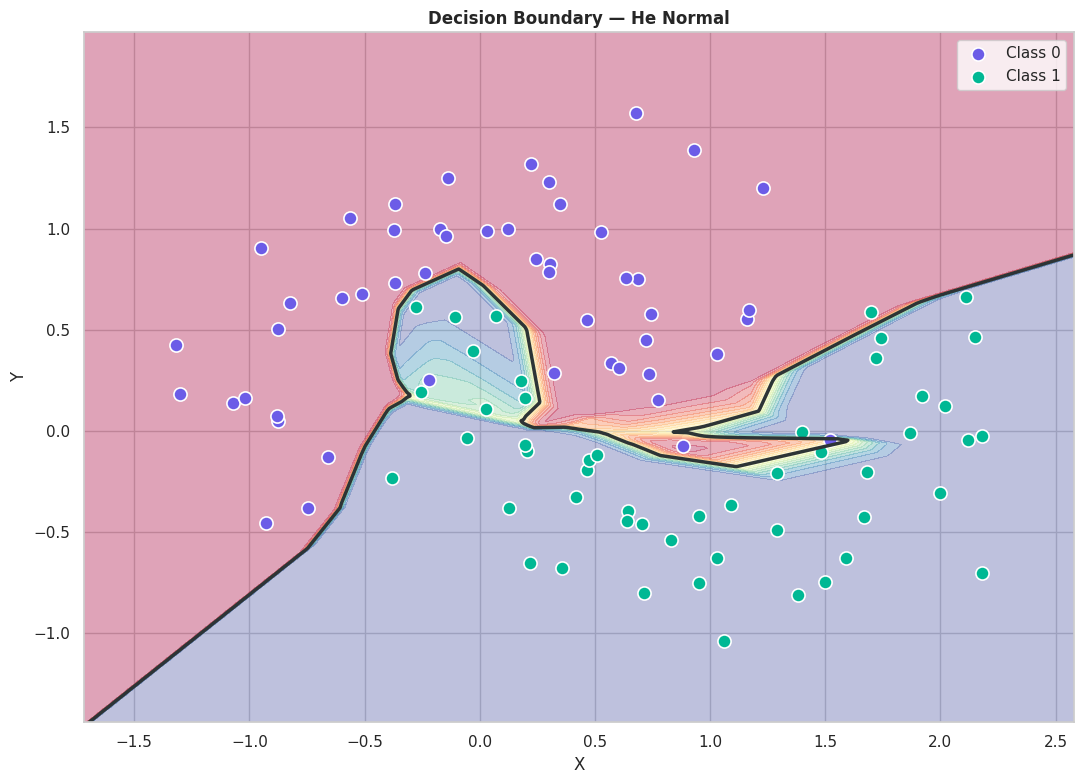

In [17]:
best_name = comparison.sort_values('Best Validation Accuracy', ascending=False).iloc[0]['Initializer']
best_model = trained_models[best_name]

x_min, x_max = X[:, 0].min() - 0.4, X[:, 0].max() + 0.4
y_min, y_max = X[:, 1].min() - 0.4, X[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
zz = best_model.predict(grid, verbose=0).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(11, 8))
ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 21), cmap='Spectral', alpha=0.38)
ax.contour(xx, yy, zz, levels=[0.5], colors=['#2D3436'], linewidths=2.5)

for label, color in zip([0, 1], ['#6C5CE7', '#00B894']):
    part = df[df['class'] == label]
    ax.scatter(part['X'], part['Y'], s=90, c=color, edgecolor='white', linewidth=1.2, label=f'Class {label}')

ax.set_title(f'Decision Boundary — {best_name}', fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
plt.tight_layout()
plt.show()

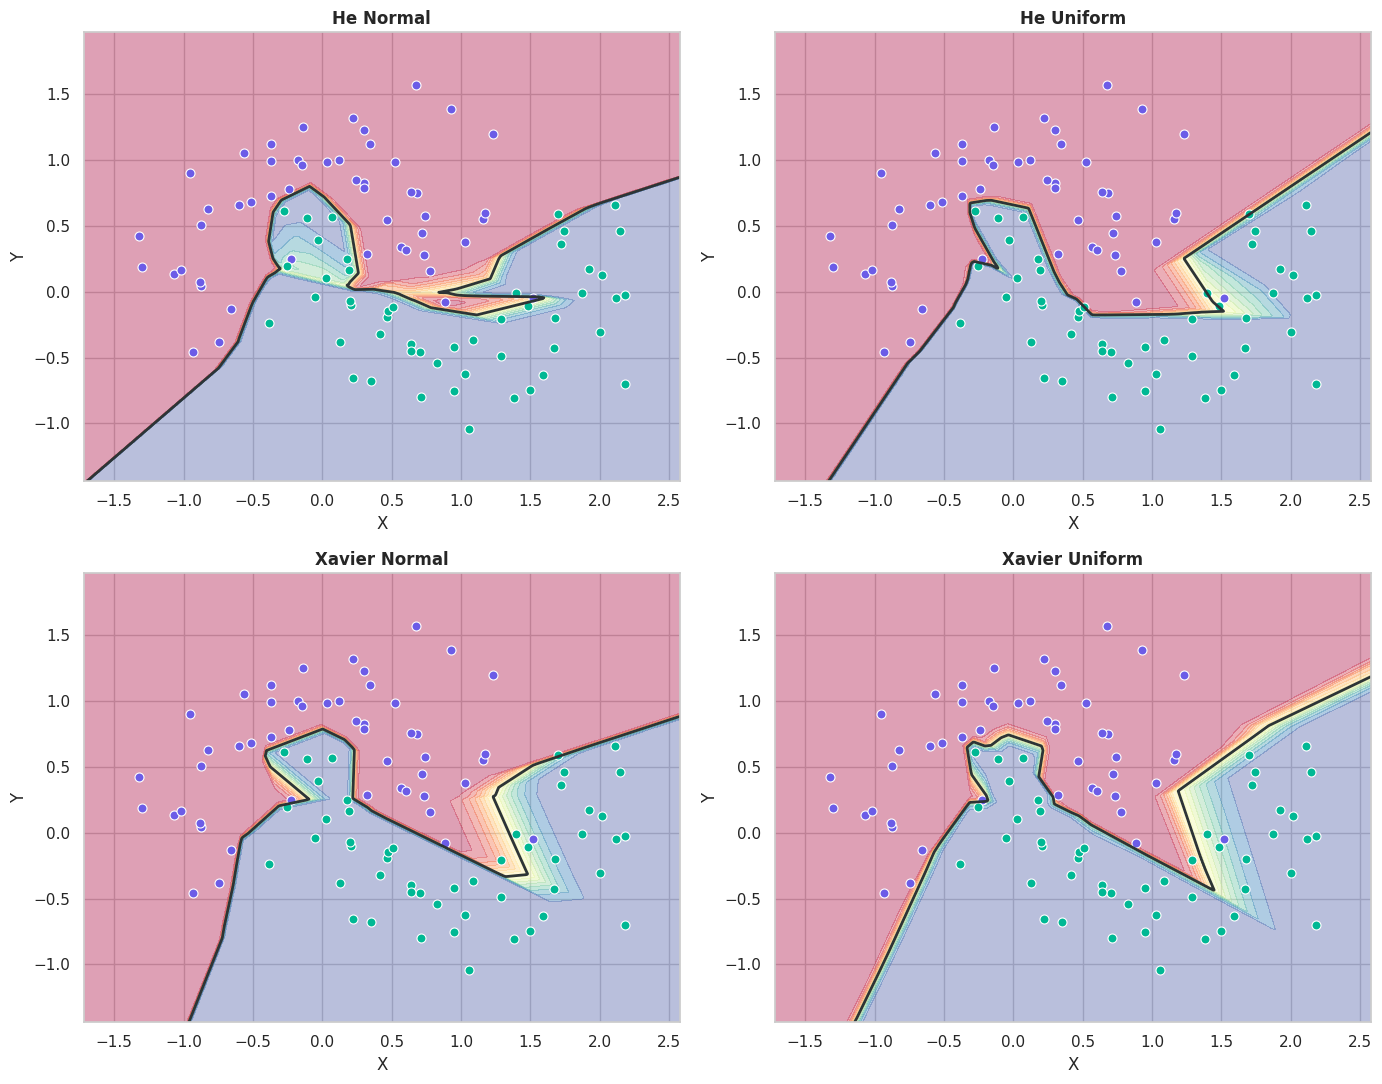

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, (name, model) in zip(axes.ravel(), trained_models.items()):
    zz = model.predict(grid, verbose=0).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(0, 1, 18), cmap='Spectral', alpha=0.4)
    ax.contour(xx, yy, zz, levels=[0.5], colors=['#2D3436'], linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], s=42, c='#6C5CE7', edgecolor='white', linewidth=0.8)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=42, c='#00B894', edgecolor='white', linewidth=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

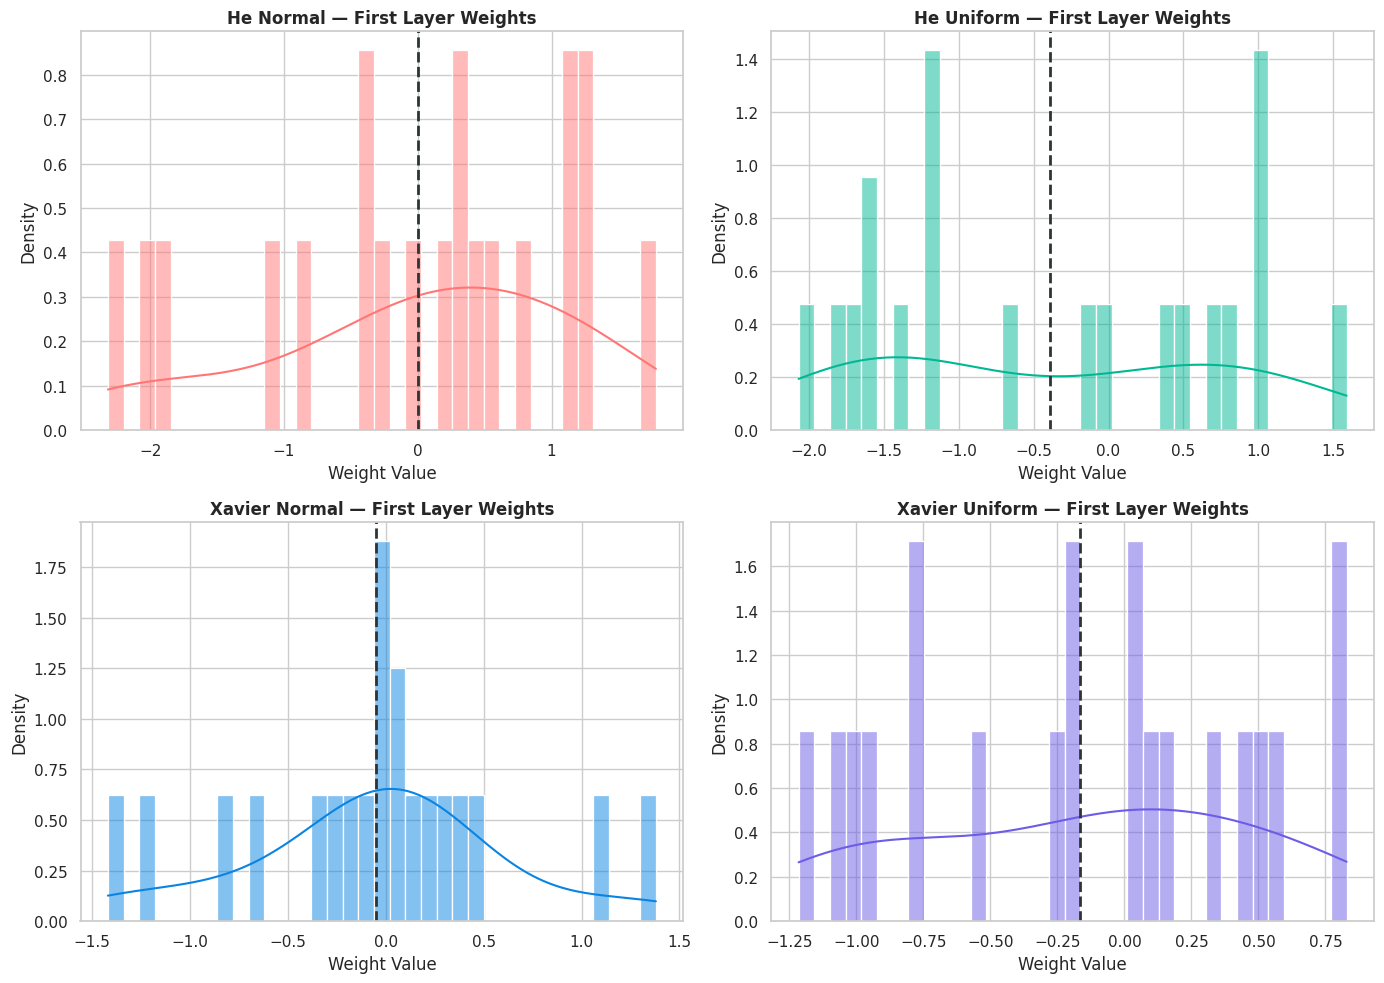

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, model) in zip(axes.ravel(), trained_models.items()):
    first_layer_weights = model.layers[0].get_weights()[0].ravel()
    sns.histplot(first_layer_weights, bins=35, kde=True, color=palette_map[name], ax=ax, stat='density')
    ax.axvline(first_layer_weights.mean(), color='#2D3436', linestyle='--', linewidth=2)
    ax.set_title(f'{name} — First Layer Weights', fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

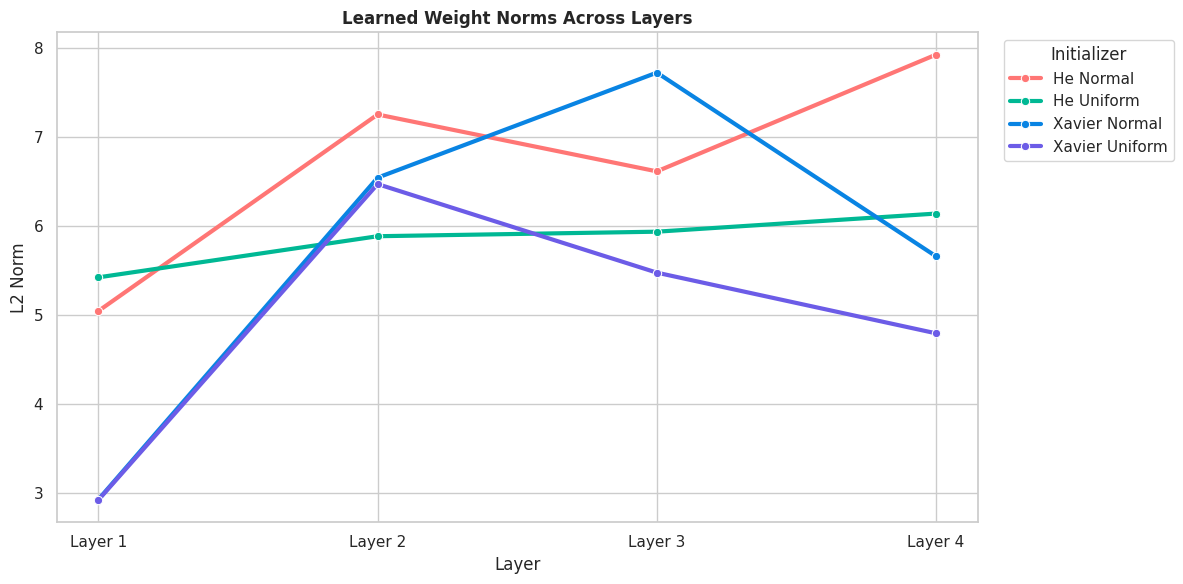

In [20]:
layer_norms = []

for name, model in trained_models.items():
    for idx, layer in enumerate(model.layers[:-1], start=1):
        w = layer.get_weights()[0]
        layer_norms.append({'Initializer': name, 'Layer': f'Layer {idx}', 'L2 Norm': np.linalg.norm(w)})

norm_df = pd.DataFrame(layer_norms)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=norm_df, x='Layer', y='L2 Norm', hue='Initializer', marker='o', linewidth=3, palette=palette_map, ax=ax)
ax.set_title('Learned Weight Norms Across Layers', fontweight='bold')
ax.set_xlabel('Layer')
ax.set_ylabel('L2 Norm')
plt.legend(title='Initializer', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
manual_model = build_model(keras.initializers.Zeros())
manual_weights = manual_model.get_weights()

manual_weights[0] = np.random.randn(2, 10) * np.sqrt(1 / 2)
manual_weights[1] = np.zeros_like(manual_weights[1])
manual_weights[2] = np.random.randn(10, 10) * np.sqrt(1 / 10)
manual_weights[3] = np.zeros_like(manual_weights[3])
manual_weights[4] = np.random.randn(10, 10) * np.sqrt(1 / 10)
manual_weights[5] = np.zeros_like(manual_weights[5])
manual_weights[6] = np.random.randn(10, 10) * np.sqrt(1 / 10)
manual_weights[7] = np.zeros_like(manual_weights[7])
manual_weights[8] = np.random.randn(10, 1) * np.sqrt(1 / 10)
manual_weights[9] = np.zeros_like(manual_weights[9])

manual_model.set_weights(manual_weights)
manual_history = manual_model.fit(X, y, epochs=200, validation_split=0.2, batch_size=16, verbose=0)
print('Final training accuracy:', manual_history.history['accuracy'][-1])
print('Final validation accuracy:', manual_history.history['val_accuracy'][-1])

Final training accuracy: 0.9624999761581421
Final validation accuracy: 1.0


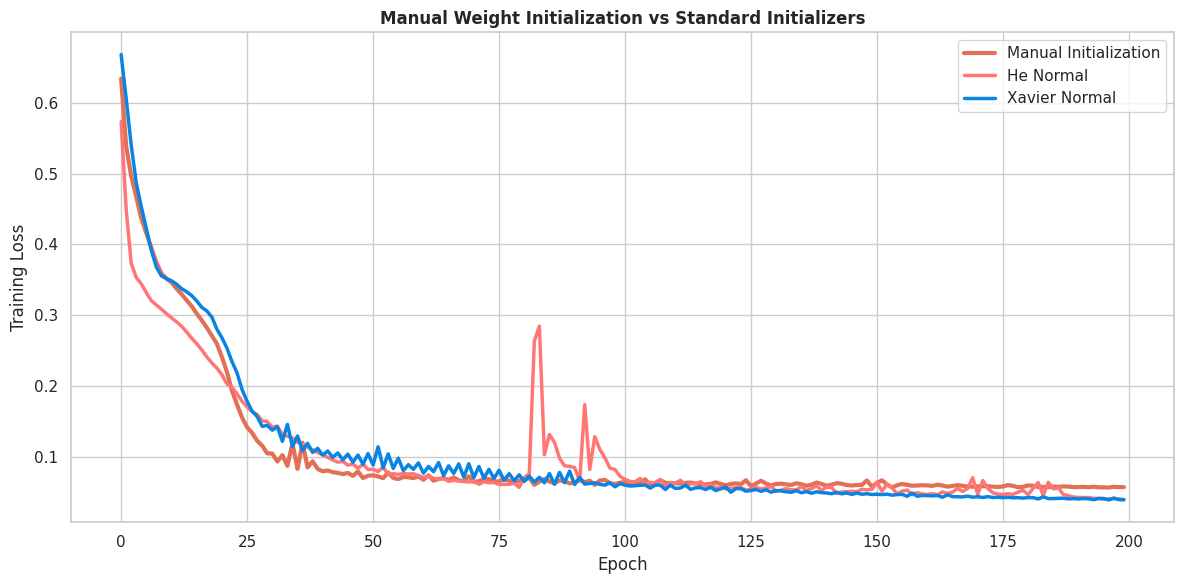

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(manual_history.history['loss'], color='#E17055', linewidth=3, label='Manual Initialization')
ax.plot(results['He Normal']['loss'], color='#FF7675', linewidth=2.5, label='He Normal')
ax.plot(results['Xavier Normal']['loss'], color='#0984E3', linewidth=2.5, label='Xavier Normal')
ax.set_title('Manual Weight Initialization vs Standard Initializers', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
summary = comparison.sort_values('Best Validation Accuracy', ascending=False).reset_index(drop=True)
winner = summary.loc[0, 'Initializer']
winner_score = summary.loc[0, 'Best Validation Accuracy']

print(f'Best initializer: {winner}')
print(f'Best validation accuracy: {winner_score:.4f}')
print('\nInterpretation:')
print('The hidden layers use ReLU activation, so He initialization is designed to preserve a useful activation scale for this setting.')
print('Xavier initialization is also a strong baseline, especially when activation behavior is closer to symmetric or when using tanh-like activations.')
print('The correct initialization scale is architecture-dependent; extremely small or large weights can make optimization ineffective.')

Best initializer: He Normal
Best validation accuracy: 1.0000

Interpretation:
The hidden layers use ReLU activation, so He initialization is designed to preserve a useful activation scale for this setting.
Xavier initialization is also a strong baseline, especially when activation behavior is closer to symmetric or when using tanh-like activations.
The correct initialization scale is architecture-dependent; extremely small or large weights can make optimization ineffective.
